# Enunciado

Energía oscura y expansión acelerada. A fines de la década de 1990, dos grupos de
investigación (Riess et. al. 1998 y Perlmutter et. al. 1999) reportaron las distancias luminosas
dL en función de los redshifts z de cientos de galaxias a partir de las observaciones de las
Supernovas Tipo Ia (SNIa). Estas mediciones son muy díficiles de realizar ya que no es trivial
reducir las fuentes de errores. Algunas de las fuentes de error importantes son los movimientos
peculiares de cada galaxia, la calibración de los métodos para medir distancia en diferentes
escalas y los errores sistemáticos en la descripción de la explosión y los parámetros de las SNIa. Explique en pocas lÍneas por qué es necesario utilizar las SNIa para medir la distancia
luminosa.

RESPUESTA

## Items

(a) Tome la expresi´on de la distancia luminosa dL(z) para un universo plano calculada
en la gu´ıa anterior. Expanda esta expresi´on para z ≪ 1 a segundo orden y escriba
los coeficientes de esta expansi´on en funci´on de H0 = ˙a0/a0 y q0 = −a0¨a0/˙a2
0. Estos
par´ametros tienen una interpretaci´on cinem´atica de la evoluci´on de a(z), ¿cu´al es para
cada uno?

(b) Utilice la expansi´on a segundo orden realizada en el punto 10a (modelo cuadr´atico) y
genere un fiteo de los par´ametros H0 y q0 sobre los datos SnIa.txt con 0 < z < 0.5, ¿qu´e
resultados obtuvo? ¿puede concluir algo? ¿podr´ıa haber utilizado la expansi´on s´olo a
primer orden?

(c)Ahora tome la expresi´on general para un universo plano y grafique sobre los datos la
curva dL(z) reemplazando H0 = 67.3 km/s/Mpc y los par´ametros de densidad por
    i.ΩΛ,0 = Ωγ,0 = 0 y Ωm,0 = 1 (Recuerde que ΩK,0 = 0 por universo plano. Podr´ıa
calcularse todo nuevamente para un universo con curvatura arbitraria).

    ii.los valores de las observaciones m´as recientes. Discuta cualitativamente la precisi´on
de ambos modelos. ¿Qu´e concluye?

# Resolución item (a)

# Resolución item (b)

In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from scipy import stats

Partiendo de la expresión de la distancia luminosa ($d_L$) para "distancias cercanas":

$$d_L(\mathcal{z}) \approx H_0^{-1} \bigg( \mathcal{z} + \frac{1 - q_0}{2} \mathcal{z}^2 \bigg)$$

Tomo el archivo de datos llamado *SnIa_data* y tomo sus valores para poder graficarlos. Notar que el ejercicio me pide que realice el ajuste para el rango de *red-shift* dentro de: $0 < \mathcal{z} < 0.5$

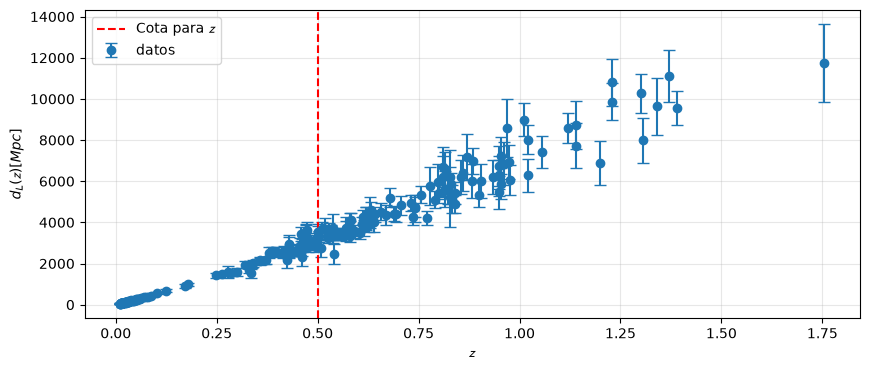

In [120]:
path_file = 'SnIa_data.txt'
df = pd.read_csv(path_file, delimiter = '\t')
df.rename(columns={'#z': 'z'}, inplace = True)

# Veo los datos
fig, ax = plt.subplots(1, 1, figsize = (10, 4))

ax.errorbar(df['z'], df['d'], 
            yerr = df['d_err'], capsize = 4,
            linestyle = 'None', fmt = 'o', label = 'datos')

ax.axvline(.5, color = 'red', linestyle = '--', label = r'Cota para $\mathcal{z}$')

ax.set(xlabel = r'$\mathcal{z}$', ylabel = r'$d_L(\mathcal{z})[Mpc]$')
ax.grid(alpha = .3), ax.legend(loc = 'upper left')

plt.show()

Infiero los parámetros a partir de la función $d_L(\mathcal{z})$ mostrada anteriormente:

$$
\begin{cases}
H_0 &= a^{-1} \\
q_0 &= 1 - \frac{2b}{a}
\end{cases}
$$

* Acá $a$ corresponde al término constante, $b$ al lineal y $c$ al cuadrático.

Realizando la propagación de errores:

$$
\begin{cases}
Var(H_0) &\approx \bigg(\frac{1}{a^2} \bigg)^2 Var(a) \\
Var(q_0) &\approx \bigg(\frac{2b}{a^2} \bigg)^2 Var(a) + \bigg(\frac{2}{a} \bigg) Var(b) - \frac{8b}{a^3} Cov(a, b)
\end{cases}
$$

A continuación realizo el ajuste y obtengo los parámetros óptimos con los datos dentro del rango $0 < \mathcal{z} < 0.5$

In [121]:
df.query('z < 0.5', inplace = True)

d = lambda z, a, b: a*z + b*z**2
popt, pcov = curve_fit(d, df['z'], df['d'], 
                       sigma = df['d_err'], absolute_sigma = True)
a, b = popt

H_0 = 1/a
q_0 = 1 - (2*b/a)

var_h0 = (1/(a**2))**2 * pcov[0][0]

var_q0 = (
    (2*b/(a**2))**2 * pcov[0][0] 
    + (2/a)**2 * pcov[1][1] 
    - (8*b/(a**3))*pcov[0][1]
)

chi2 = np.sum(
    (df['d'] - d(df['z'], *popt))**2 
    / df['d_err']**2
    )

p_value = stats.chi2.sf(chi2, df = len(df) - len(popt))

H0 = (0.00021387183539567012 +- 3.1352333094598187e-06)
q0 = (-0.40294663094145045 +- 0.1323646368754939)
0.9414460764345495


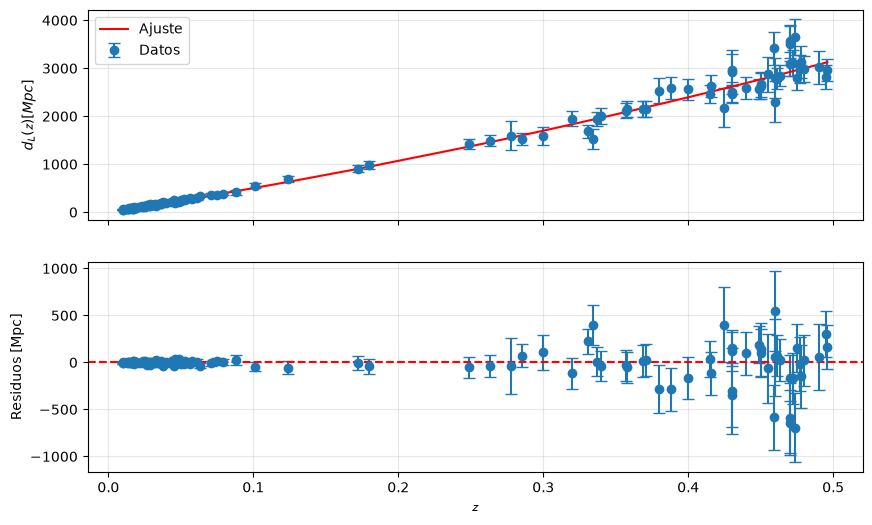

In [122]:
print(f'H0 = ({H_0} +- {np.sqrt(var_h0)})')
print(f'q0 = ({q_0} +- {np.sqrt(var_q0)})')
print(p_value)

fig, axs = plt.subplots(2, 1, figsize = (10, 6), sharex = True)

axs[0].errorbar(df['z'], df['d'], yerr = df['d_err'],
                capsize = 4, linestyle = 'None', 
                fmt = 'o', label = 'Datos')

axs[0].plot(df['z'], d(df['z'], *popt), 
            color = 'red', label = 'Ajuste')

axs[0].set(ylabel = r'$d_L(\mathcal{z})[Mpc]$')
axs[0].grid(alpha = .3), axs[0].legend(loc = 'upper left')

# Residuos
axs[1].errorbar(df['z'], d(df['z'], *popt) - df['d'], 
                yerr = df['d_err'], fmt = 'o',
                linestyle = 'None', capsize = 4)
axs[1].set(ylabel = 'Residuos [Mpc]', xlabel = r'$\mathcal{z}$')
axs[1].axhline(0, color = 'red', linestyle = '--')
axs[1].grid(alpha = .3)


## Resolución item (c)

Los datos que da el ejercicio son para que pueda hallar una expresión de $H(\mathcal{z})$ utilizando las ecuaciones de Friedmann:

$$H(\mathcal{z})^{2} = H_0^2 \bigg[ \Omega_{\gamma, 0} (1 + \mathcal{z})^{4} + \Omega_{m, 0} (1 + \mathcal{z})^{3} + \Omega_{\Lambda, 0} \bigg]$$

Los contenidos energéticos propuestos por el ejercicio son:
i. Solo contenido en forma de polvo ($\Omega_{m,0} = 1$):
$$

    H(\mathcal{z}) = H_0 (1 + \mathcal{z})^{3/2} \longrightarrow d_L(\mathcal{z}) = (1 + \mathcal{z}) \int_0^{\mathcal{z}} \frac{d\mathcal{z}}{H_0(1 + \mathcal{z})^{3/2}} = \frac{1 + \mathcal{z}}{2H_0} \bigg(1 - \frac{1}{ \sqrt{1 + \mathcal{z}} }\bigg)

$$

ii. En el pdg dice, asumiendo $\kappa = 0$, que $\Omega_{m,0} \approx 0.3$ y $\Omega_{\Lambda, 0} \approx 0.7$ (dan valores mas precisos pero así me ahorro escribir $\Omega_{\gamma, 0}$). Por lo tanto, la expresión mas reducible de forma análitica es:
$$

    d_L(\mathcal{z}) = \frac{1 + \mathcal{z}}{H_0} \int_0^{\mathcal{z}} \frac{d\mathcal{z}}{\sqrt{\Omega_{m, 0}(1 + \mathcal{z})^3 + \Omega_{\Lambda, 0}}}

$$


Realizo los gráficos correspondientes a estas dos expresiones tomando, como dice el enunciado, $H_0 = 67.3$ km/s/Mpc con el cuidado de que en las ecuaciones donde dice $H_0$ estoy utilizando unidades naturales donde $c = 1$, por lo que tengo que convertir este valor al que tengo en las ecuaciones:

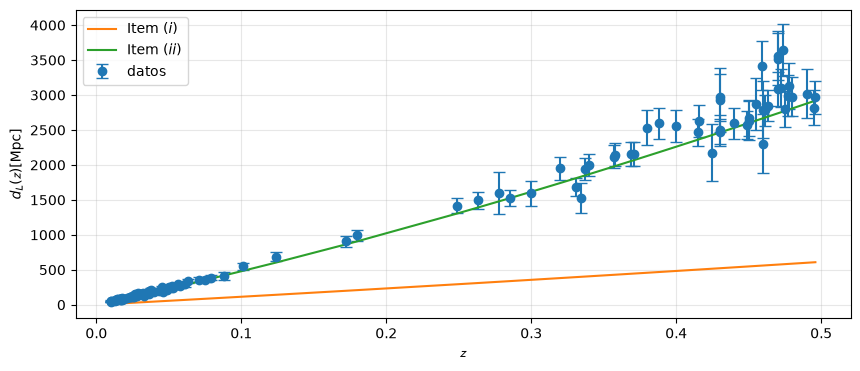

In [123]:
H0_enunciado = 67.3 #km/s/Mpc
c = 300_000 #km/s
H0 = H0_enunciado/c
def dL1(z, H0 = H0):
    ffactor = (1 + z)/(2 * H0)
    sfactor = 1 - 1/np.sqrt(1 + z)
    return ffactor * sfactor

def dL2(z, H0 = H0, Om = .3, Olam = .7):
    ffactor = (1 + z)/(H0)

    int_return = []
    for x in z:
        z_ = np.linspace(0, x, 1_000)
        arg_int = 1/np.sqrt(Om*(1 + z_)**3 + Olam)
        integral = np.trapezoid(y = arg_int, x = z_)
        int_return.append(integral)
    return ffactor * np.array(int_return)

fig, ax = plt.subplots(1, 1, figsize = (10, 4))

ax.errorbar(df['z'], df['d'], 
            yerr = df['d_err'], capsize = 4,
            linestyle = 'None', fmt = 'o', label = 'datos')

ax.plot(df['z'], dL1(df['z']), label = r'Item $(i)$')
ax.plot(df['z'], dL2(df['z']), label = r'Item $(ii)$')

ax.set(xlabel = r'$\mathcal{z}$', ylabel = r'$d_L(\mathcal{z})$[Mpc]')
ax.grid(alpha = .3), ax.legend(loc = 'upper left')

plt.show()

El ejercicio también propone que podemos inferir nosotros los parámetos. Para esto escribo $H(\mathcal{z})$ utilizando la ecuación de Friedmann y para la regresión le doy como puntos iniciales a aquellos items que se encuentran en el [pdg](https://pdg.lbl.gov/2024/reviews/astro-cosmo.html):

$$H(\mathcal{z})^{2} = H_0^2 \bigg[ \Omega_{\gamma, 0} (1 + \mathcal{z})^{4} + \Omega_{m, 0} (1 + \mathcal{z})^{3} + \Omega_{\kappa, 0}(1 + \mathcal{z})^{2} + \Omega_{\Lambda, 0}\bigg]$$

A diferencia del código de arriba, voy a liberar todas las mediciones teniendo en cuenta aquellas que tienen $\mathcal{z} < 0.5$ para que el ajuste pueda tener mayor cantidad de datos

In [124]:
def dl_ajuste(z, H0, Og, Om, Ok, Ol):
    ffactor = (1 + z)/H0

    int_result = []
    for x in z:
        x_ = np.linspace(0, x, 1_000)
        arg_int = 1/np.sqrt(Og*(1 + x_)**4 + Om*(1 + x_)**3 + Ok*(1 + x_)**2 + Ol)
        int_result.append(np.trapezoid(arg_int, x_))
    return ffactor * np.array(int_result)

datos = pd.read_csv(path_file, delimiter = '\t')
datos.rename(columns = {'#z':'z'}, inplace = True)
popt, pcov = curve_fit(dl_ajuste, datos['z'], datos['d'],
                       sigma = datos['d_err'], absolute_sigma = True,
                       p0 = [H0_enunciado/c, 5E-5, .31, 0, .69])

H0_a,Og_a, Om_a, Ok_a, Ol_a = popt
varH0, VarOg, VarOm, VarOk, VarOl = np.diag(pcov)

chi2_a = np.sum(
    (datos['d'] - dl_ajuste(datos['z'], *popt))**2
    / datos['d_err']**2
)

p_value_a = stats.chi2.sf(chi2_a, df = len(datos) - len(popt))

H0 = (93.00724482248475 +- 0.9405699928379456)
Omega_g = (-0.010167596345944432 +- 5689.618328158025)
Omega_m = (0.5600356981433026 +- 313381.6649113927)
Omega_k = (-0.7312308475344665 +- 409177.9920546342)
Omega_l = (0.6641562105178143 +- 371644.4958840154)
0.9409227950130938


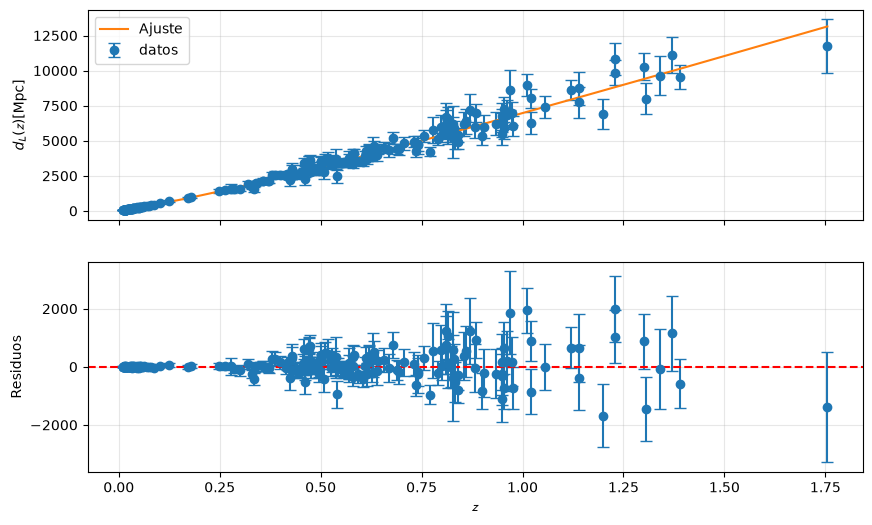

In [125]:
#Reporte de los valores:
print(f'H0 = ({H0_a*c} +- {np.sqrt(var_h0)*c})')
print(f'Omega_g = ({Og_a} +- {np.sqrt(VarOg)})')
print(f'Omega_m = ({Om_a} +- {np.sqrt(VarOm)})')
print(f'Omega_k = ({Ok_a} +- {np.sqrt(VarOk)})')
print(f'Omega_l = ({Ol_a} +- {np.sqrt(VarOl)})')
print(p_value_a)


#Visualización del ajuste
fig, axs = plt.subplots(2, 1, figsize = (10, 6), sharex = True)

axs[0].errorbar(datos['z'], datos['d'], 
            yerr = datos['d_err'], capsize = 4,
            linestyle = 'None', fmt = 'o', label = 'datos')

d_ajuste = dl_ajuste(datos['z'], *popt)
axs[0].plot(datos['z'], d_ajuste, label = 'Ajuste')

axs[0].set(ylabel = r'$d_L(\mathcal{z})$[Mpc]')
axs[0].grid(alpha = .3), axs[0].legend(loc = 'upper left')

axs[1].errorbar(datos['z'], datos['d'] - d_ajuste, yerr = datos['d_err'],
               linestyle = 'None', fmt = 'o', capsize = 4)
axs[1].axhline(0, linestyle = '--', color = 'red')

axs[1].set(ylabel = 'Residuos', xlabel = r'$\mathcal{z}$'), axs[1].grid(alpha = .3)

plt.show()

Son demasiados grados de libertad, entonces reduciendolos puedo lograr mejores valores (mas cercanos a los tabulados hoy en dia)